In [1]:
import sys
import os

from pathlib import Path
sys.path.append(str(Path().resolve().parent))
str(Path().resolve().parent)

ROOT = Path(os.getcwd()).resolve().parent
ROOT

PosixPath('/Users/mohamedmafaz/Desktop/CFD_DiT')

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import pandas as pd
from scipy.interpolate import griddata
import matplotlib.ticker as tkr

from DDPM import LinearNoiseScheduler
from DiT_model import DiT
from VAE import VAE

In [3]:
import json
with open("../config/config.json", "r") as file:
    config = json.load(file)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vae = VAE(device = device, freeze = True, scaling_factor = config["VAE"]["scaling_factor"], path = f"{ROOT}/pretrained/sd-vae-ft-mse").to(device)

num_timesteps = 1000
beta_start    = 0.0001
beta_end      = 0.02


scheduler = LinearNoiseScheduler(num_timesteps  = num_timesteps,
                                     beta_start = beta_start,
                                     beta_end   = beta_end)


In [5]:
dit = DiT(d_model          = config["DiT"]["d_model"],
          g_channels       = config["DiT"]["g_channels"],
          grid_size        = config["DiT"]["grid_size"],
          patch_size       = config["DiT"]["patch_size"],
          timestep_emb_dim = config["DiT"]["timestep_emb_dim"],
          number_emb_dim   = config["DiT"]["number_emb_dim"],
          num_layers       = config["DiT"]["num_layers"],
          num_heads        = config["DiT"]["num_heads"])

vae.eval()
dit.eval()

# vae.load_state_dict(torch.load('vae_v2.pth', map_location = device))
dit.load_state_dict(torch.load(f'{ROOT}/DiT.pth', map_location = device))

<All keys matched successfully>

In [6]:
@torch.no_grad()
def sample(latent_grid_size: int, dit, vae, device, scheduler, number):
    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    for i in tqdm(reversed(range(1000))):
        noise_pred = dit(xt, 
                         torch.as_tensor(i).unsqueeze(0).to(device), 
                         torch.as_tensor(number).unsqueeze(0).to(device))

        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

    img_tensor = vae.decode(x0_pred)
    return img_tensor

In [7]:
@torch.no_grad()
def sample_ddim(latent_grid_size, dit, vae, device, scheduler, number, num_steps=50, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    # e.g. [999, 979, 959, ..., 19, -1]  (evenly spaced, descending)
    step_indices = torch.linspace(0, 999, num_steps).long().flip(0)
    step_indices = torch.cat([step_indices, torch.tensor([-1])])  # -1 = terminal, x0

    for idx in tqdm(range(len(step_indices) - 1)):
        t = step_indices[idx].item()
        t_prev = step_indices[idx + 1].item()

        noise_pred = dit(xt,
                          torch.as_tensor(t).unsqueeze(0).to(device),
                          torch.as_tensor(number).unsqueeze(0).to(device))

        xt, x0_pred = scheduler.ddim_step(xt, noise_pred, t, t_prev, eta=0.0)

    img_tensor = vae.decode(x0_pred)
    return img_tensor

In [8]:
def predict(re_value, sample_fn, 
            re_mean, re_std, 
            u_mean, u_std, 
            v_mean, v_std, 
            P_mean, P_std, 
            grid_size,
            device="cpu", plot: bool = True, **kwargs):
    '''
    magic
    '''
        
    # img = sample_fn(32, dit, vae, device, scheduler, re_value)
    img = sample_fn(32, dit, vae, device, scheduler, (re_value - re_mean) / re_std, kwargs)

    img_np = np.array(img)

    img_np = img_np[0]


    u = (img_np[0] * u_std) + u_mean
    v = (img_np[1] * v_std) + v_mean
    p = (img_np[2] * P_std) + P_mean

    mag = np.sqrt(u**2 + v**2)

    du_dx = np.gradient(u, axis = 1) # derivative along x (cols)
    du_dy = np.gradient(u, axis = 0)
    dv_dy = np.gradient(v, axis = 0) # derivative along y (rows)
    dv_dx = np.gradient(v, axis = 1)


    d2u_dx2 = np.gradient(du_dx, axis = 1)
    d2u_dy2 = np.gradient(du_dy, axis = 0)
    d2v_dy2 = np.gradient(dv_dy, axis = 0)
    d2v_dx2 = np.gradient(dv_dx, axis = 1)


    dP_dx = np.gradient(p, axis = 1)
    dP_dy = np.gradient(p, axis = 0)


    momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
    momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

    momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

    divergence = du_dx + dv_dy

    if plot:
        # u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
        # v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

        # plot
        x_grid = np.linspace(0, 1, grid_size)
        y_grid = np.linspace(0, 1, grid_size)


        fig, axes = plt.subplots(1, 6, figsize=(30, 5))

        # u
        c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
        fig.colorbar(c0, ax=axes[0])
        axes[0].set_title("u (m/s)")

        # v
        c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
        fig.colorbar(c1, ax=axes[1])
        axes[1].set_title("v (m/s)")

        # p
        c2 = axes[2].contourf(x_grid, y_grid, p, levels=300, cmap="jet")
        fig.colorbar(c2, ax=axes[2])
        axes[2].set_title("P (Pa)")

        # mag
        c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
        fig.colorbar(c3, ax=axes[3])
        axes[3].set_title("|U|")


        c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
        fig.colorbar(c4, ax=axes[4], label="∇·u")
        axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

        div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
        plt.colorbar(div_m, ax=axes[5])
        axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
        axes[5].set_xlabel("x")
        axes[5].set_ylabel("y")

        plt.suptitle(f"Re = {re_value}")
        plt.tight_layout()
        plt.show()

    return u, v, p, divergence, momentum_res, mag

In [9]:
RE_MEAN = config["Stats"]["Re_Mean"]
RE_STD = config["Stats"]["Re_Std"]

U_MEAN = config["Stats"]["U_MEAN"]
U_STD = config["Stats"]["U_STD"]

V_MEAN = config["Stats"]["V_MEAN"]
V_STD = config["Stats"]["V_STD"]

P_MEAN = config["Stats"]["P_MEAN"]
P_STD = config["Stats"]["P_STD"]

In [10]:
u, v, P, divergence, momentum_res, mag = predict(re_value = 2500, sample_fn = sample_ddim, 
                                   re_mean = RE_MEAN, re_std = RE_STD, 
                                   u_mean = U_MEAN,   u_std = U_STD, 
                                   v_mean = V_MEAN,   v_std = V_STD, 
                                   P_mean = P_MEAN,   P_std = P_STD,
                                   grid_size = 256,
                                   device = "cpu", plot = True
                                   )

TypeError: linspace() received an invalid combination of arguments - got (int, int, dict), but expected one of:
 * (Tensor start, Tensor end, int steps, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (Number start, Tensor end, int steps, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (Tensor start, Number end, int steps, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (Number start, Number end, int steps, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)


1000it [00:43, 23.20it/s]


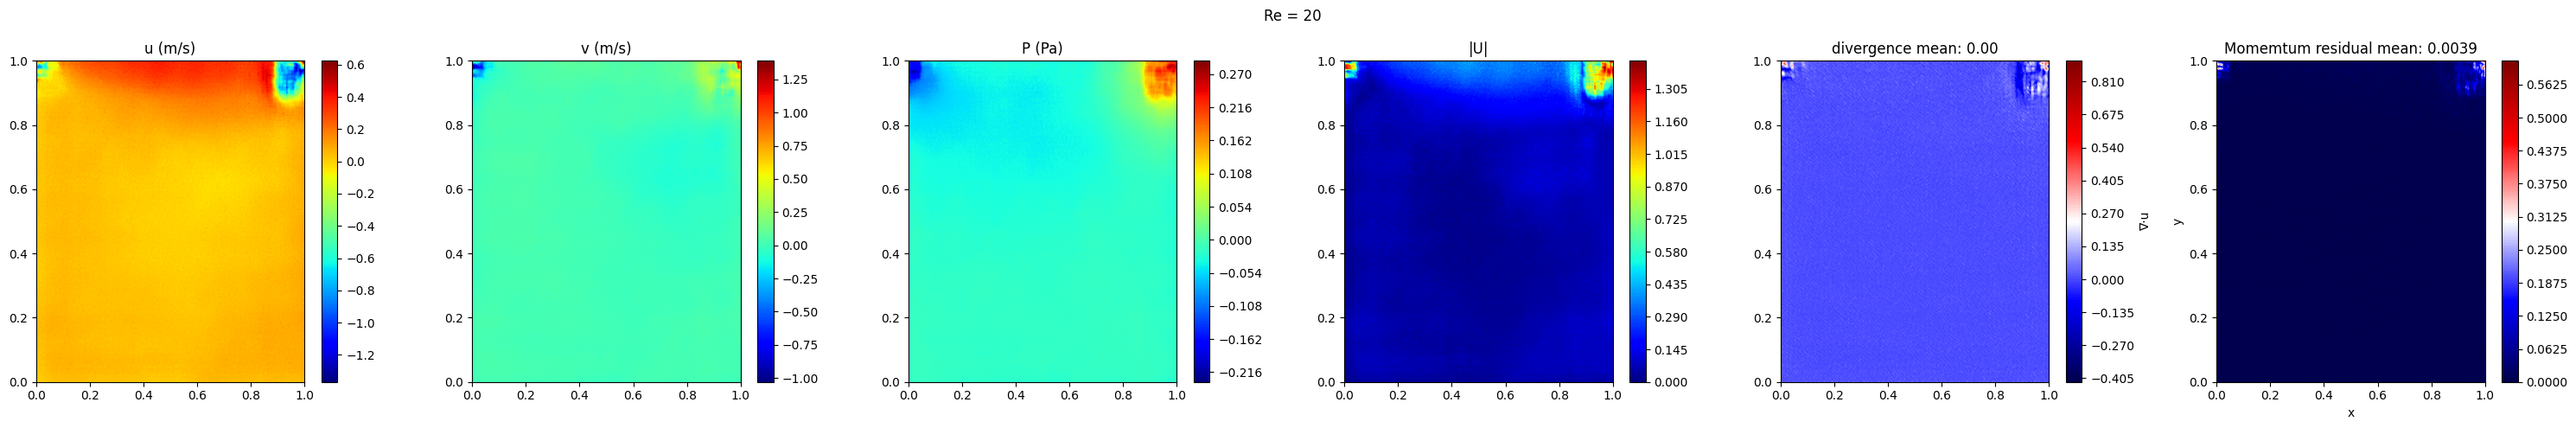

In [10]:
u, v, P, divergence, momentum_res, mag = predict(re_value = 20, sample_fn = sample, 
                                                 re_mean = RE_MEAN, re_std = RE_STD, 
                                                 u_mean = U_MEAN,   u_std = U_STD, 
                                                 v_mean = V_MEAN,   v_std = V_STD, 
                                                 P_mean = P_MEAN,   P_std = P_STD,
                                                 grid_size = 256,
                                                 device = "cpu", plot = True
                                                 )

In [4]:
from torch.utils.data import Dataset, DataLoader
from Data import dataset_cfd

In [5]:
dataset    = dataset_cfd.dataset_csv(folder = f"{ROOT}/Data/Problems/{config['Data']['name']}", meta = "Lid_Driven")
dataloader = DataLoader(dataset, batch_size = 1, shuffle=True, num_workers=2)

In [7]:
worst = -float("inf")
worst_file = None
for idx in tqdm(range(len(dataset))):
    uvp, num, mask = dataset[idx]
    m = np.abs(uvp).max()
    if m > worst:
        worst = m
        worst_file = dataset.all_pths[idx]
        # print(worst, worst_file)
print(worst, worst_file)

100%|██████████| 320/320 [07:31<00:00,  1.41s/it]

612.6491 /Users/mohamedmafaz/Desktop/CFD_DiT/Data/Problems/Lid_Driven_domain/Re_8.43.csv


In [ ]:
min_val = torch.tensor(torch.inf)
max_val = torch.tensor(-torch.inf)

for uvp_grids, r, mask in tqdm(dataloader):
    min_val = min(min_val, uvp_grids.min())
    max_val = max(max_val, uvp_grids.max())

min_val, max_val

 43%|████▎     | 139/320 [02:08<02:37,  1.15it/s]

In [19]:
uvp_grids[0][0].min()

tensor(-0.2754)

In [71]:
uvp_grids, r, mask = next(iter(dataloader))

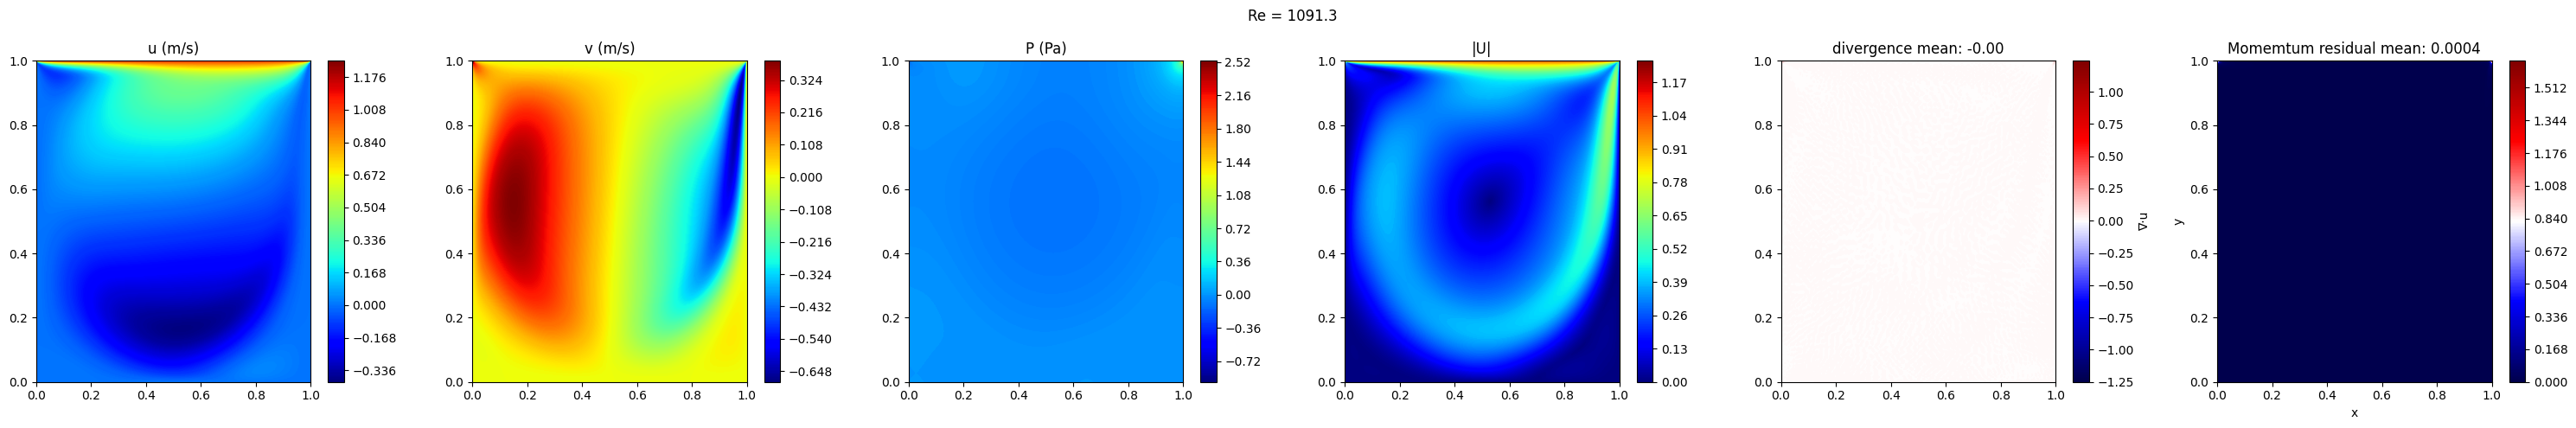

In [ ]:
uvp_grid = uvp_grids[0]
re_value = (r.item() * RE_STD) + RE_MEAN

u = (uvp_grid[0] * U_STD) + U_MEAN
v = (uvp_grid[1] * V_STD) + V_MEAN
p = (uvp_grid[2] * P_STD) + P_MEAN

mag = np.sqrt(u**2 + v**2)

du_dx = np.gradient(u, axis = 1) # derivative along x (cols)
du_dy = np.gradient(u, axis = 0)
dv_dy = np.gradient(v, axis = 0) # derivative along y (rows)
dv_dx = np.gradient(v, axis = 1)


d2u_dx2 = np.gradient(du_dx, axis = 1)
d2u_dy2 = np.gradient(du_dy, axis = 0)
d2v_dy2 = np.gradient(dv_dy, axis = 0)
d2v_dx2 = np.gradient(dv_dx, axis = 1)


dP_dx = np.gradient(p, axis = 1)
dP_dy = np.gradient(p, axis = 0)


momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

divergence = du_dx + dv_dy


# u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
# v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

# plot
x_grid = np.linspace(0, 1, 256)
y_grid = np.linspace(0, 1, 256)


fig, axes = plt.subplots(1, 6, figsize=(30, 5))

# u
c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
fig.colorbar(c0, ax=axes[0])
axes[0].set_title("u (m/s)")

# v
c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
fig.colorbar(c1, ax=axes[1])
axes[1].set_title("v (m/s)")

# p
c2 = axes[2].contourf(x_grid, y_grid, p, levels=300, cmap="jet")
fig.colorbar(c2, ax=axes[2])
axes[2].set_title("P (Pa)")

# mag
c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
fig.colorbar(c3, ax=axes[3])
axes[3].set_title("|U|")


c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
fig.colorbar(c4, ax=axes[4], label="∇·u")
axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")


div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
plt.colorbar(div_m, ax=axes[5])
axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
axes[5].set_xlabel("x")
axes[5].set_ylabel("y")

plt.suptitle(f"Re = {re_value}")
plt.tight_layout()
plt.show()

In [ ]:
mu, logvar = vae.encode(uvp_grids)
recon = vae.decode(mu)

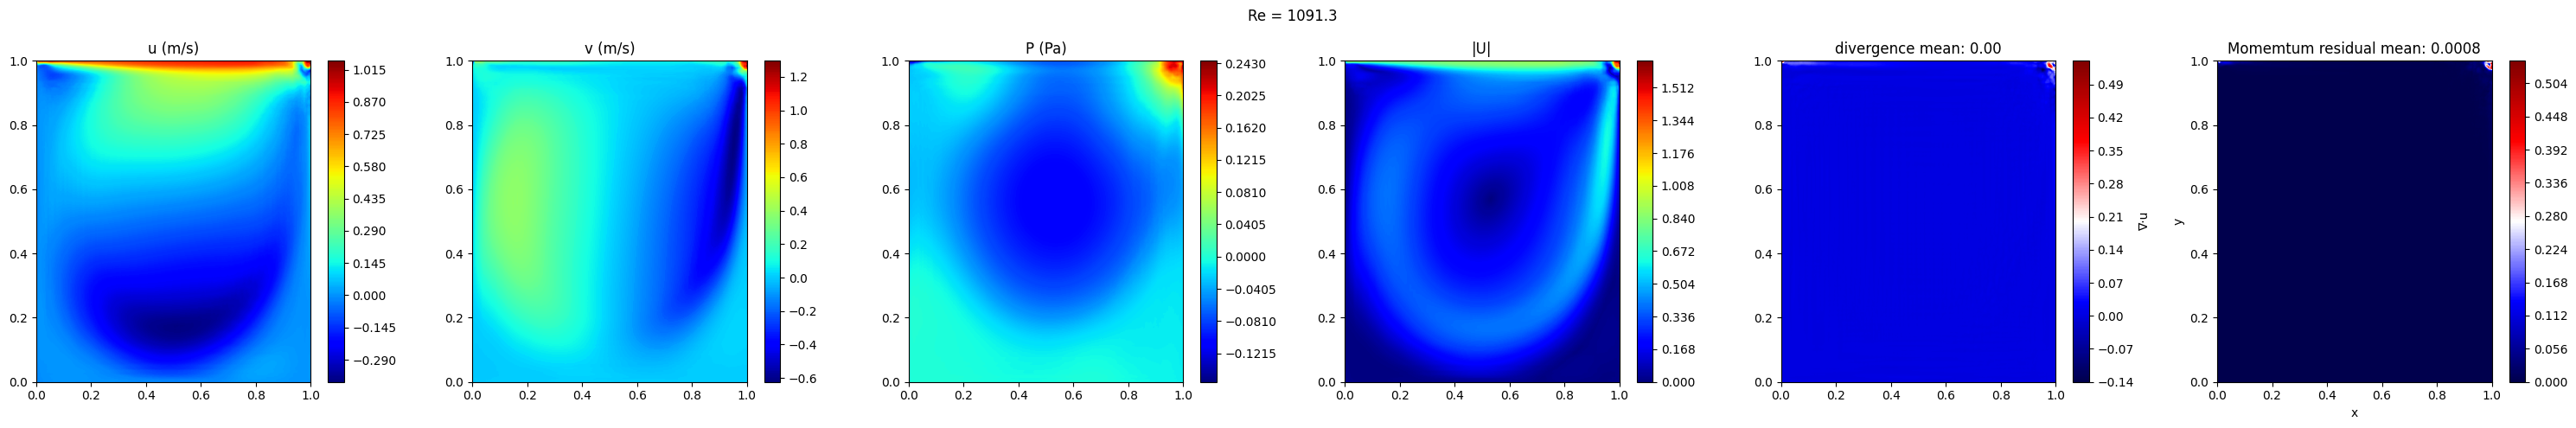

In [76]:
uvp_grid = recon[0]
re_value = (r.item() * RE_STD) + RE_MEAN

u = (uvp_grid[0] * U_STD) + U_MEAN
v = (uvp_grid[1] * V_STD) + V_MEAN
p = (uvp_grid[2] * P_STD) + P_MEAN

mag = np.sqrt(u**2 + v**2)

du_dx = np.gradient(u, axis = 1) # derivative along x (cols)
du_dy = np.gradient(u, axis = 0)
dv_dy = np.gradient(v, axis = 0) # derivative along y (rows)
dv_dx = np.gradient(v, axis = 1)


d2u_dx2 = np.gradient(du_dx, axis = 1)
d2u_dy2 = np.gradient(du_dy, axis = 0)
d2v_dy2 = np.gradient(dv_dy, axis = 0)
d2v_dx2 = np.gradient(dv_dx, axis = 1)


dP_dx = np.gradient(p, axis = 1)
dP_dy = np.gradient(p, axis = 0)


momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

divergence = du_dx + dv_dy


# u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
# v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

# plot
x_grid = np.linspace(0, 1, 256)
y_grid = np.linspace(0, 1, 256)


fig, axes = plt.subplots(1, 6, figsize=(30, 5))

# u
c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
fig.colorbar(c0, ax=axes[0])
axes[0].set_title("u (m/s)")

# v
c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
fig.colorbar(c1, ax=axes[1])
axes[1].set_title("v (m/s)")

# p
c2 = axes[2].contourf(x_grid, y_grid, p, levels=300, cmap="jet")
fig.colorbar(c2, ax=axes[2])
axes[2].set_title("P (Pa)")

# mag
c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
fig.colorbar(c3, ax=axes[3])
axes[3].set_title("|U|")


c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
fig.colorbar(c4, ax=axes[4], label="∇·u")
axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
plt.colorbar(div_m, ax=axes[5])
axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
axes[5].set_xlabel("x")
axes[5].set_ylabel("y")

plt.suptitle(f"Re = {re_value}")
plt.tight_layout()
plt.show()

In [14]:
# pick one actual training example
images, numbers, mask = next(iter(dataloader))
true_number = numbers[0].item()      # already normalized, matches training distribution

with torch.no_grad():
    mu, logvar = vae.encode(images.to(device))
    z_true = mu[0:1]                 # ground truth latent, no reparam noise

# sample from scratch using that exact training Re
img = sample(32, dit, vae, device, scheduler, true_number)

# compare img (decoded generation) against vae.decode(z_true) (ground truth)

1000it [00:45, 22.12it/s]


In [ ]:
vae.decode(z_true)

torch.Size([4, 32, 32])

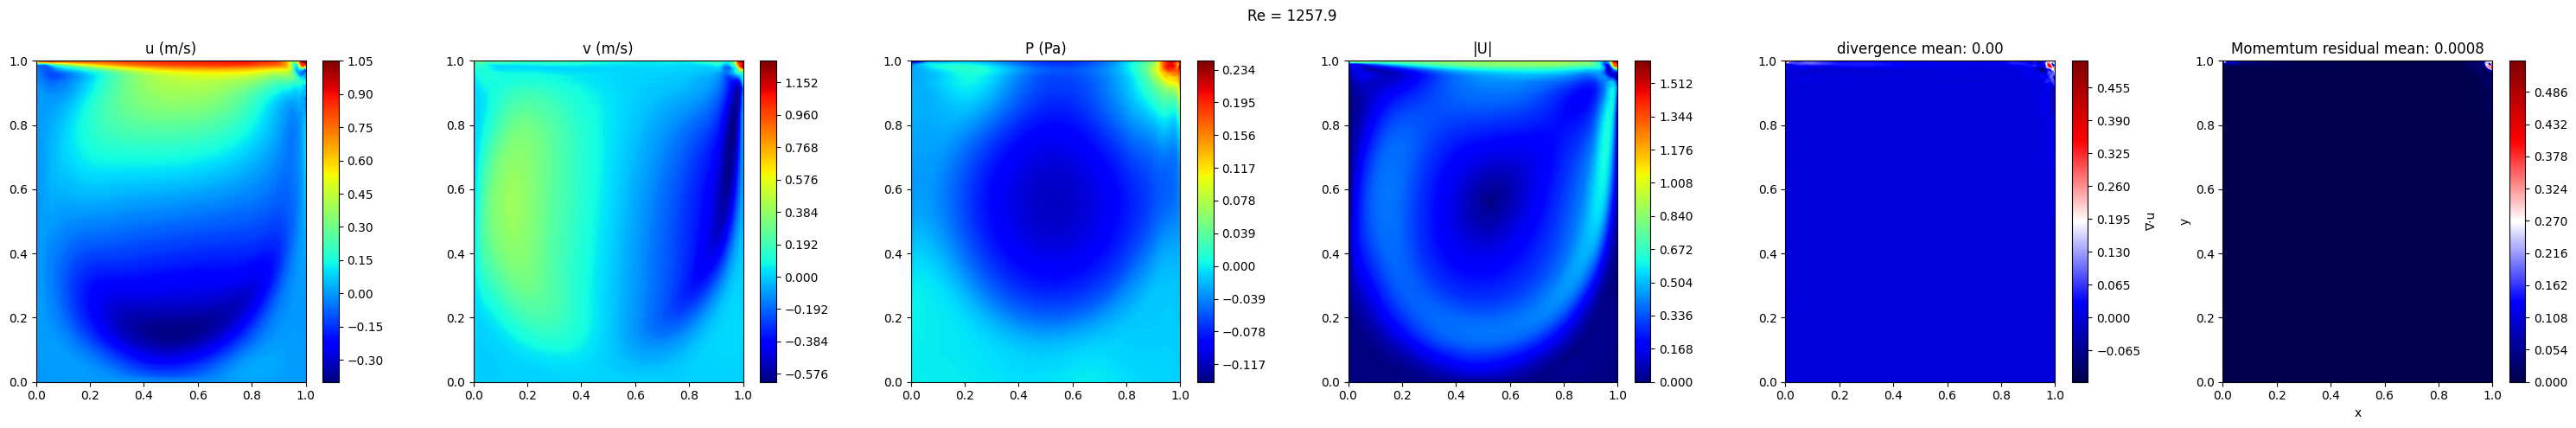

In [19]:
uvp_grid = vae.decode(z_true)[0]
re_value = (numbers.item() * RE_STD) + RE_MEAN

u = (uvp_grid[0] * U_STD) + U_MEAN
v = (uvp_grid[1] * V_STD) + V_MEAN
p = (uvp_grid[2] * P_STD) + P_MEAN

mag = np.sqrt(u**2 + v**2)

du_dx = np.gradient(u, axis = 1) # derivative along x (cols)
du_dy = np.gradient(u, axis = 0)
dv_dy = np.gradient(v, axis = 0) # derivative along y (rows)
dv_dx = np.gradient(v, axis = 1)


d2u_dx2 = np.gradient(du_dx, axis = 1)
d2u_dy2 = np.gradient(du_dy, axis = 0)
d2v_dy2 = np.gradient(dv_dy, axis = 0)
d2v_dx2 = np.gradient(dv_dx, axis = 1)


dP_dx = np.gradient(p, axis = 1)
dP_dy = np.gradient(p, axis = 0)


momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

divergence = du_dx + dv_dy


# u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
# v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

# plot
x_grid = np.linspace(0, 1, 256)
y_grid = np.linspace(0, 1, 256)


fig, axes = plt.subplots(1, 6, figsize=(30, 5))

# u
c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
fig.colorbar(c0, ax=axes[0])
axes[0].set_title("u (m/s)")

# v
c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
fig.colorbar(c1, ax=axes[1])
axes[1].set_title("v (m/s)")

# p
c2 = axes[2].contourf(x_grid, y_grid, p, levels=300, cmap="jet")
fig.colorbar(c2, ax=axes[2])
axes[2].set_title("P (Pa)")

# mag
c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
fig.colorbar(c3, ax=axes[3])
axes[3].set_title("|U|")


c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
fig.colorbar(c4, ax=axes[4], label="∇·u")
axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
plt.colorbar(div_m, ax=axes[5])
axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
axes[5].set_xlabel("x")
axes[5].set_ylabel("y")

plt.suptitle(f"Re = {re_value}")
plt.tight_layout()
plt.show()